2nd iter

added patientID as a categorical feature

In [1]:
# Imports
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error

DATA_PATH = Path("../assets/dataset/CSV/diabetes_all_patients_code.csv")

TARGET_CODES = {"58", "60", "62", "64"}          # pre-meal glucose targets
GLUCOSE_CODES = {"48", "57", "58", "59", "60", "61", "62", "63", "64"}

INSULIN_CODES = {
    "33": "regular_insulin",
    "34": "nph_insulin",
    "35": "ultralente_insulin",
}

In [2]:
# Load and clean the CSV
df = pd.read_csv(DATA_PATH, sep=None, engine="python")

df["patientId"] = df["patientId"].astype(int)
df["Day"] = pd.to_numeric(df["Day"], errors="coerce")
df["MinuteOfDay"] = pd.to_numeric(df["MinuteOfDay"], errors="coerce")
df["Code"] = df["Code"].astype(str)

# Convert values like "009" to 9. Invalid glucose strings become NaN.
df["ValueNum"] = pd.to_numeric(df["Value"], errors="coerce")

# Absolute patient-relative time, useful for "previous X hours" features.
df["AbsMinute"] = (df["Day"] - 1) * 1440 + df["MinuteOfDay"]

df = df.dropna(subset=["Day", "MinuteOfDay", "AbsMinute"])
df = df.sort_values(["patientId", "AbsMinute"]).reset_index(drop=True)

df.head(30)


,patientId,Day,MinuteOfDay,Code,Value,CodeMeaning,ValueNum,AbsMinute
0,1,1,549.0,58,100,Pre-breakfast blood glucose measurement,100.0,549.0
1,1,1,549.0,33,009,Regular insulin dose,9.0,549.0
2,1,1,549.0,34,013,NPH insulin dose,13.0,549.0
3,1,1,1028.0,62,119,Pre-supper blood glucose measurement,119.0,1028.0
4,1,1,1028.0,33,007,Regular insulin dose,7.0,1028.0
5,1,1,1371.0,48,123,Unspecified blood glucose measurement,123.0,1371.0
6,1,2,455.0,58,216,Pre-breakfast blood glucose measurement,216.0,1895.0
7,1,2,455.0,33,010,Regular insulin dose,10.0,1895.0
8,1,2,455.0,34,013,NPH insulin dose,13.0,1895.0
9,1,2,820.0,33,002,Regular insulin dose,2.0,2260.0


In [3]:
# Build supervised rows
# Each row becomes: predictors from the past -> current pre-meal glucose target.

def build_modeling_rows(patient_df):
    rows = []
    history = []

    for _, row in patient_df.iterrows():
        code = row["Code"]
        t = row["AbsMinute"]
        value = row["ValueNum"]

        # If this row is a target glucose measurement, create one training example.
        if code in TARGET_CODES and pd.notna(value):
            prior = [event for event in history if event["time"] < t]

            def prior_events(codes, hours):
                cutoff = t - hours * 60
                return [e for e in prior if e["code"] in codes and e["time"] >= cutoff]

            def sum_values(codes, hours):
                events = prior_events(codes, hours)
                return sum(e["value"] for e in events if pd.notna(e["value"]))

            def count_events(codes, hours):
                return len(prior_events(codes, hours))

            previous_glucose = [
                e for e in prior
                if e["code"] in GLUCOSE_CODES and pd.notna(e["value"])
            ]

            if previous_glucose:
                last_glucose = previous_glucose[-1]
                prev_glucose_value = last_glucose["value"]
                hours_since_prev_glucose = (t - last_glucose["time"]) / 60
            else:
                prev_glucose_value = np.nan
                hours_since_prev_glucose = np.nan

            minute = row["MinuteOfDay"]

            rows.append({
                "patientId": row["patientId"],
                "target_code": code,
                "Day": row["Day"],
                "MinuteOfDay": minute,
                "time_sin": np.sin(2 * np.pi * minute / 1440),
                "time_cos": np.cos(2 * np.pi * minute / 1440),

                "prev_glucose": prev_glucose_value,
                "hours_since_prev_glucose": hours_since_prev_glucose,

                "regular_insulin_8h": sum_values({"33"}, 8),
                "nph_insulin_24h": sum_values({"34"}, 24),
                "ultralente_insulin_24h": sum_values({"35"}, 24),

                "typical_meal_6h": count_events({"66"}, 6),
                "more_meal_6h": count_events({"67"}, 6),
                "less_meal_6h": count_events({"68"}, 6),

                "typical_exercise_6h": count_events({"69"}, 6),
                "more_exercise_6h": count_events({"70"}, 6),
                "less_exercise_6h": count_events({"71"}, 6),

                "hypo_symptoms_24h": count_events({"65"}, 24),
                "special_event_24h": count_events({"72"}, 24),

                "glucose": value,
            })

        # Add current event after feature creation so same-time insulin is not leaked.
        history.append({
            "time": t,
            "code": code,
            "value": value,
        })

    return rows


model_rows = []
for _, patient_df in df.groupby("patientId"):
    model_rows.extend(build_modeling_rows(patient_df))

model_df = pd.DataFrame(model_rows)

print(model_df.shape)
model_df.head()

(10346, 20)


,patientId,target_code,Day,MinuteOfDay,time_sin,time_cos,prev_glucose,hours_since_prev_glucose,regular_insulin_8h,nph_insulin_24h,ultralente_insulin_24h,typical_meal_6h,more_meal_6h,less_meal_6h,typical_exercise_6h,more_exercise_6h,less_exercise_6h,hypo_symptoms_24h,special_event_24h,glucose
0,1,58,1,549.0,0.678801,-0.734323,NaN,NaN,0.0,0.0,0.0,0,0,0,0,0,0,0,0,100.0
1,1,62,1,1028.0,-0.974370,-0.224951,100.0,7.983333,9.0,13.0,0.0,0,0,0,0,0,0,0,0,119.0
2,1,58,2,455.0,0.915311,-0.402747,123.0,8.733333,0.0,13.0,0.0,0,0,0,0,0,0,0,0,216.0
3,1,62,2,1016.0,-0.961262,-0.275637,216.0,9.350000,2.0,13.0,0.0,0,0,0,0,0,0,0,0,211.0
4,1,58,3,445.0,0.932008,-0.362438,211.0,14.483333,0.0,13.0,0.0,0,0,0,0,0,0,0,0,257.0


In [4]:
# This lets the model learn patient-specific glucose baselines.

feature_cols = [
    "patientId",
    "target_code",
    "Day",
    "MinuteOfDay",
    "time_sin",
    "time_cos",
    "prev_glucose",
    "hours_since_prev_glucose",
    "regular_insulin_8h",
    "nph_insulin_24h",
    "ultralente_insulin_24h",
    "typical_meal_6h",
    "more_meal_6h",
    "less_meal_6h",
    "typical_exercise_6h",
    "more_exercise_6h",
    "less_exercise_6h",
    "hypo_symptoms_24h",
    "special_event_24h",
]

X = pd.get_dummies(model_df[feature_cols], columns=["patientId", "target_code"], drop_first=False)
y = model_df["glucose"]

X.head()


,Day,MinuteOfDay,time_sin,time_cos,prev_glucose,hours_since_prev_glucose,regular_insulin_8h,nph_insulin_24h,ultralente_insulin_24h,typical_meal_6h,...,patientId_62,patientId_63,patientId_65,patientId_67,patientId_68,patientId_70,target_code_58,target_code_60,target_code_62,target_code_64
0,1,549.0,0.678801,-0.734323,NaN,NaN,0.0,0.0,0.0,0,...,False,False,False,False,False,False,True,False,False,False
1,1,1028.0,-0.974370,-0.224951,100.0,7.983333,9.0,13.0,0.0,0,...,False,False,False,False,False,False,False,False,True,False
2,2,455.0,0.915311,-0.402747,123.0,8.733333,0.0,13.0,0.0,0,...,False,False,False,False,False,False,True,False,False,False
3,2,1016.0,-0.961262,-0.275637,216.0,9.350000,2.0,13.0,0.0,0,...,False,False,False,False,False,False,False,False,True,False
4,3,445.0,0.932008,-0.362438,211.0,14.483333,0.0,13.0,0.0,0,...,False,False,False,False,False,False,True,False,False,False


In [5]:
'''
# Time-based train/test split within each patient
# This tests whether earlier patient history can predict later patient glucose.

model_df["target_number"] = model_df.groupby("patientId").cumcount()
model_df["target_count"] = model_df.groupby("patientId")["patientId"].transform("count")

train_mask = model_df["target_number"] < 0.8 * model_df["target_count"]

X_train = X.loc[train_mask]
X_test = X.loc[~train_mask]
y_train = y.loc[train_mask]
y_test = y.loc[~train_mask]

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
'''

# Time-based train/test split within each patient using DAYS
# For each patient: first 80% of recorded days -> train, last 20% -> test.
train_mask = pd.Series(False, index=model_df.index)

for patient_id, patient_rows in model_df.groupby("patientId"):
    days = sorted(patient_rows["Day"].dropna().unique())
    split_index = int(np.ceil(0.8 * len(days)))

    train_days = set(days[:split_index])

    patient_train_mask = (
        (model_df["patientId"] == patient_id) &
        (model_df["Day"].isin(train_days))
    )

    train_mask = train_mask | patient_train_mask

test_mask = ~train_mask

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]
y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))


Train rows: 8444
Test rows: 1902


In [6]:
# Baseline models

def evaluate_predictions(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    return {
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "Selected Predictors": np.nan,
    }


results = []

# Baseline 1: predict the training mean glucose.
mean_pred = np.full(len(y_test), y_train.mean())
results.append(evaluate_predictions("Mean baseline", y_test, mean_pred))

# Baseline 2: predict using previous glucose when available.
prev_pred = X_test["prev_glucose"].fillna(y_train.mean())
results.append(evaluate_predictions("Previous glucose baseline", y_test, prev_pred))

'''
# Basline 3: Patient + target-code baseline:
# predict each patient's average glucose for that measurement type.
train_df = model_df.loc[train_mask].copy()
test_df = model_df.loc[~train_mask].copy()

global_mean = train_df["glucose"].mean()
patient_means = train_df.groupby("patientId")["glucose"].mean()
patient_code_means = train_df.groupby(["patientId", "target_code"])["glucose"].mean()

patient_code_pred = []

for _, row in test_df.iterrows():
    key = (row["patientId"], row["target_code"])

    if key in patient_code_means:
        patient_code_pred.append(patient_code_means[key])
    elif row["patientId"] in patient_means:
        patient_code_pred.append(patient_means[row["patientId"]])
    else:
        patient_code_pred.append(global_mean)

results.append(
    evaluate_predictions(
        "Patient + target-code baseline",
        y_test,
        patient_code_pred
    )
)
'''
# Baseline 3: Patient average baseline
# Predict each patient's average training glucose, regardless of measurement type.

train_df = model_df.loc[train_mask].copy()
test_df = model_df.loc[test_mask].copy()

global_mean = train_df["glucose"].mean()
patient_means = train_df.groupby("patientId")["glucose"].mean()

patient_mean_pred = (
    test_df["patientId"]
    .map(patient_means)
    .fillna(global_mean)
)

results.append(
    evaluate_predictions(
        "Patient average baseline",
        y_test,
        patient_mean_pred
    )
)


pd.DataFrame(results)


,Model,MSE,RMSE,MAE,Selected Predictors
0,Mean baseline,5891.123437,76.753654,62.505170,NaN
1,Previous glucose baseline,9194.173502,95.886253,70.567823,NaN
2,Patient + target-code baseline,4954.792381,70.390286,54.691903,NaN


In [7]:
# Train Ridge, LASSO, and Elastic Net

alphas = np.logspace(-3, 3, 50)

models = {
    "Ridge": RidgeCV(alphas=alphas),
    "LASSO": LassoCV(alphas=alphas, cv=5, max_iter=20000, random_state=0),
    "Elastic Net": ElasticNetCV(
        alphas=alphas,
        l1_ratio=[0.2, 0.5, 0.8, 0.95, 1.0],
        cv=5,
        max_iter=20000,
        random_state=0,
    ),
}

fitted_models = {}

for name, model in models.items():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model),
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    coef = pipe.named_steps["model"].coef_
    selected = np.sum(np.abs(coef) > 1e-8)

    row = evaluate_predictions(name, y_test, pred)
    row["Selected Predictors"] = selected
    results.append(row)

    fitted_models[name] = pipe

results_df = pd.DataFrame(results).sort_values("MSE")
results_df

,Model,MSE,RMSE,MAE,Selected Predictors
3,Ridge,4924.237908,70.172914,55.358211,86.0
4,LASSO,4952.979558,70.377408,55.741738,43.0
5,Elastic Net,4952.979558,70.377408,55.741738,43.0
2,Patient + target-code baseline,4954.792381,70.390286,54.691903,NaN
0,Mean baseline,5891.123437,76.753654,62.505170,NaN
1,Previous glucose baseline,9194.173502,95.886253,70.567823,NaN


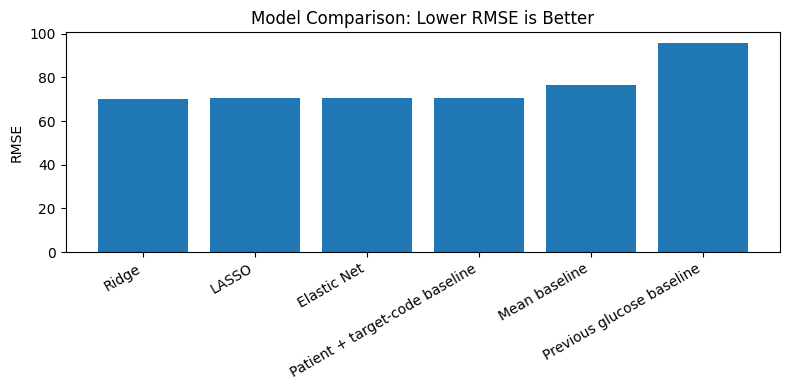

In [8]:
# Plot model performance

plt.figure(figsize=(8, 4))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.ylabel("RMSE")
plt.title("Model Comparison: Lower RMSE is Better")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [9]:
# Inspect selected predictors from the final model

final_model = fitted_models["Elastic Net"]
coefs = pd.Series(
    final_model.named_steps["model"].coef_,
    index=X.columns
)

selected_predictors = (
    coefs[coefs.abs() > 1e-8]
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("Selected predictor count:", len(selected_predictors))
selected_predictors


Selected predictor count: 43


patientId_50               -8.637885
patientId_65                7.314298
patientId_49               -6.599443
prev_glucose                6.202544
patientId_68               -5.861613
target_code_60             -4.911740
patientId_70                4.198714
patientId_52               -4.028233
patientId_51               -3.809532
patientId_2                 3.650690
patientId_27               -3.402141
patientId_62                3.345687
patientId_20                3.240641
patientId_67                3.026346
patientId_56                2.992561
patientId_3                -2.857221
hours_since_prev_glucose    2.801350
patientId_63                2.680880
target_code_58              2.633823
patientId_59                2.489534
patientId_58                2.324529
patientId_10                2.249570
nph_insulin_24h            -2.204850
patientId_42               -2.107662
patientId_61                2.061019
patientId_60               -1.687788
patientId_54               -1.653067
p

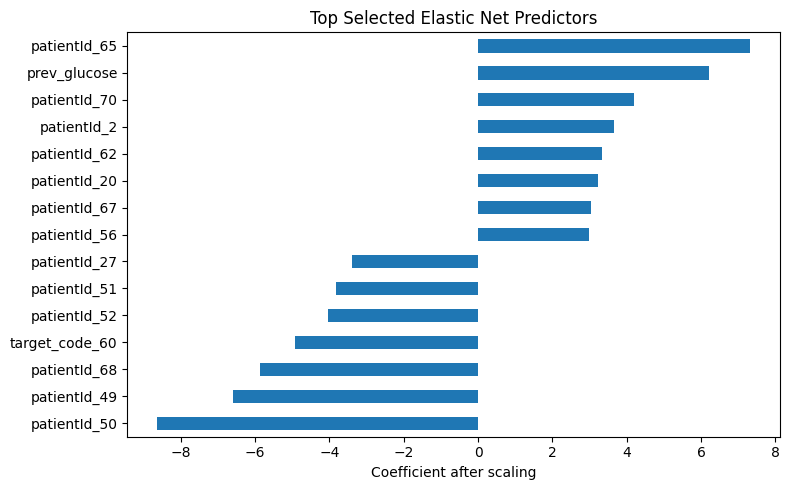

In [10]:
# Plot selected coefficients

selected_predictors.head(15).sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Top Selected Elastic Net Predictors")
plt.xlabel("Coefficient after scaling")
plt.tight_layout()
plt.show()


In [11]:
# Custom objective function for the assignment writeup
# This matches the elastic net objective:
# MSE term + L1 sparsity penalty + L2 stability penalty.

def elastic_net_objective(y_true, y_pred, beta, lambda_value, l1_ratio):
    mse_term = 0.5 * np.mean((y_true - y_pred) ** 2)
    l1_term = lambda_value * l1_ratio * np.sum(np.abs(beta))
    l2_term = 0.5 * lambda_value * (1 - l1_ratio) * np.sum(beta ** 2)
    return mse_term + l1_term + l2_term

elastic = fitted_models["Elastic Net"]
elastic_model = elastic.named_steps["model"]

elastic_pred = elastic.predict(X_test)
elastic_beta = elastic_model.coef_

objective_value = elastic_net_objective(
    y_test,
    elastic_pred,
    elastic_beta,
    lambda_value=elastic_model.alpha_,
    l1_ratio=elastic_model.l1_ratio_,
)

print("Elastic Net alpha:", elastic_model.alpha_)
print("Elastic Net l1_ratio:", elastic_model.l1_ratio_)
print("Elastic Net objective value:", objective_value)

Elastic Net alpha: 1.151395399326447
Elastic Net l1_ratio: 1.0
Elastic Net objective value: 2602.9937446025424


In [12]:
# Final short summary for the presentation
best_row = results_df.iloc[0]

print("Final selected model:", best_row["Model"])
print("Test MSE:", round(best_row["MSE"], 2))
print("Test RMSE:", round(best_row["RMSE"], 2))
print("Test MAE:", round(best_row["MAE"], 2))
print("Selected predictors:", best_row["Selected Predictors"])


Final selected model: Ridge
Test MSE: 4924.24
Test RMSE: 70.17
Test MAE: 55.36
Selected predictors: 86.0
